In [184]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [185]:
data = pd.read_csv("../data/processed/clean_data.csv")

## Distributions and correlations exploration

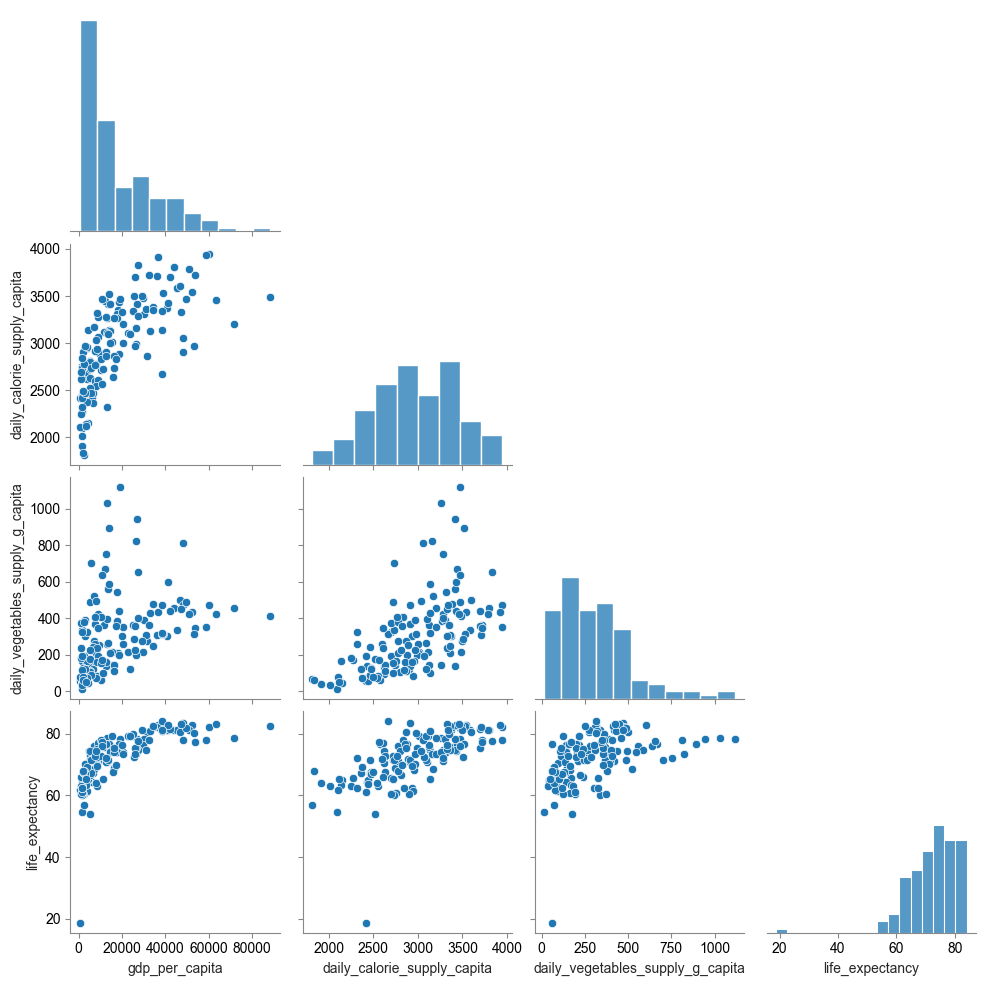

In [186]:
cols = ['gdp_per_capita',
       'daily_calorie_supply_capita', 'daily_vegetables_supply_g_capita', 'life_expectancy']

# conducting the analysis for the most recent year
data_latest = data[data['year'] == 2022]

sns.pairplot(
    data_latest[cols + ['country_wb_income_group']],
    diag_kind='hist',
    corner=True
    )

There seems to be a rather strong positive relation between life expecatncy and GDP per capita. And some positive relation between calorie supply and life expectancy. There also seems to be some positive relation for vegetable supply but very vague.

There also seems to be a cluster of outliers with unusually high vegetable supply which does not follow the usual patterns. I want to take a closer look at that as well.

## Outlier investigation and removal

There is a clear outlier in terms of life expectancy and I will exclude it from further exploration for a more robust analysis.

In [187]:
data_latest[data_latest['life_expectancy'] == min(data_latest['life_expectancy'])]

,country,year,gdp_per_capita,life_expectancy,daily_calorie_supply_capita,daily_vegetables_supply_g_capita,country_wb_income_group
743,Central African Republic,2022,596.393,18.8177,2418.7656,58.976049,Low-income countries


>"In 2022, the Central African Republic (CAR) experienced a severe, ongoing humanitarian crisis driven by armed conflict, widespread violence against civilians, and economic collapse. Key issues included intense fighting between government forces (FACA)—backed by Russian mercenaries—and rebel groups (CPC), leading to mass displacement and serious human rights abuses." - AI summary based on Wikipedia and Freedom House website

Based on this information it is clear that the causes for extreme low life expectancy for CAR can not be explained by the dependent variables analysed here and therefore excluding it from the dataset will contribute positively to the accuracy of the analysis.

In [188]:
outlier_life_exp = min(data_latest['life_expectancy'])

In [189]:
data_robust = data_latest[data_latest['life_expectancy'] != outlier_life_exp]

## Data exploration without outlier present

### Basic statistics

In [244]:
data_robust[cols].describe()

,gdp_per_capita,daily_calorie_supply_capita,daily_vegetables_supply_g_capita,life_expectancy
count,141.000000,141.000000,141.000000,141.000000
mean,18412.613467,2977.390993,308.351541,72.817601
std,17427.965813,472.806209,208.348938,6.995994
min,811.214600,1814.448500,14.628682,54.079000
25%,5070.492700,2636.740000,144.082192,67.674700
50%,12801.671000,2972.160400,275.287575,74.125000
75%,27220.303000,3344.939700,411.397562,78.002900
max,88366.220000,3947.213900,1115.369918,84.054100


In [233]:
data_robust[data_robust['life_expectancy'] == min(data_robust['life_expectancy'])]

,country,year,gdp_per_capita,life_expectancy,daily_calorie_supply_capita,daily_vegetables_supply_g_capita,country_wb_income_group,log_gdp,calories_thousands,daily_vegetables_supply_kg_capita,pos_veg_outliers,prediction_log_gdp
3037,Nigeria,2022,5070.4927,54.079,2520.64,178.60274,Lower-middle-income countries,8.531193,2.52064,0.178603,False,68.748989


In [234]:
data_robust[data_robust['life_expectancy'] == max(data_robust['life_expectancy'])]

,country,year,gdp_per_capita,life_expectancy,daily_calorie_supply_capita,daily_vegetables_supply_g_capita,country_wb_income_group,log_gdp,calories_thousands,daily_vegetables_supply_kg_capita,pos_veg_outliers,prediction_log_gdp
2076,Japan,2022,38268.79,84.0541,2670.09,315.801041,High-income countries,10.55239,2.67009,0.315801,False,79.571675


In [235]:
data_robust[data_robust['gdp_per_capita'] == min(data_robust['gdp_per_capita'])]

,country,year,gdp_per_capita,life_expectancy,daily_calorie_supply_capita,daily_vegetables_supply_g_capita,country_wb_income_group,log_gdp,calories_thousands,daily_vegetables_supply_kg_capita,pos_veg_outliers,prediction_log_gdp
2386,Liberia,2022,811.2146,61.9342,2105.6973,78.438255,Low-income countries,6.698533,2.105697,0.078438,False,58.935837


In [236]:
data_robust[data_robust['gdp_per_capita'] == max(data_robust['gdp_per_capita'])]

,country,year,gdp_per_capita,life_expectancy,daily_calorie_supply_capita,daily_vegetables_supply_g_capita,country_wb_income_group,log_gdp,calories_thousands,daily_vegetables_supply_kg_capita,pos_veg_outliers,prediction_log_gdp
3099,Norway,2022,88366.22,82.6309,3486.8923,411.397562,High-income countries,11.389245,3.486892,0.411398,False,84.052693


In [237]:
data_robust[data_robust['daily_calorie_supply_capita'] == min(data_robust['daily_calorie_supply_capita'])]

,country,year,gdp_per_capita,life_expectancy,daily_calorie_supply_capita,daily_vegetables_supply_g_capita,country_wb_income_group,log_gdp,calories_thousands,daily_vegetables_supply_kg_capita,pos_veg_outliers,prediction_log_gdp
2355,Lesotho,2022,2312.9583,56.8119,1814.4485,69.369805,Lower-middle-income countries,7.746283,1.814448,0.06937,False,64.546112


In [238]:
data_robust[data_robust['daily_calorie_supply_capita'] == max(data_robust['daily_calorie_supply_capita'])]

,country,year,gdp_per_capita,life_expectancy,daily_calorie_supply_capita,daily_vegetables_supply_g_capita,country_wb_income_group,log_gdp,calories_thousands,daily_vegetables_supply_kg_capita,pos_veg_outliers,prediction_log_gdp
1952,Ireland,2022,60257.082,82.0505,3947.2139,471.589507,High-income countries,11.006375,3.947214,0.47159,False,82.002582


In [239]:
data_robust[data_robust['daily_vegetables_supply_g_capita'] == min(data_robust['daily_vegetables_supply_g_capita'])]

,country,year,gdp_per_capita,life_expectancy,daily_calorie_supply_capita,daily_vegetables_supply_g_capita,country_wb_income_group,log_gdp,calories_thousands,daily_vegetables_supply_kg_capita,pos_veg_outliers,prediction_log_gdp
774,Chad,2022,1393.5635,54.5275,2097.067,14.628682,Low-income countries,7.239619,2.097067,0.014629,False,61.833137


In [240]:
data_robust[data_robust['daily_vegetables_supply_g_capita'] == max(data_robust['daily_vegetables_supply_g_capita'])]

,country,year,gdp_per_capita,life_expectancy,daily_calorie_supply_capita,daily_vegetables_supply_g_capita,country_wb_income_group,log_gdp,calories_thousands,daily_vegetables_supply_kg_capita,pos_veg_outliers,prediction_log_gdp
836,China,2022,19238.18,78.2021,3472.2903,1115.369918,Upper-middle-income countries,9.864652,3.47229,1.11537,True,75.889119


### Distributions and scatterplots

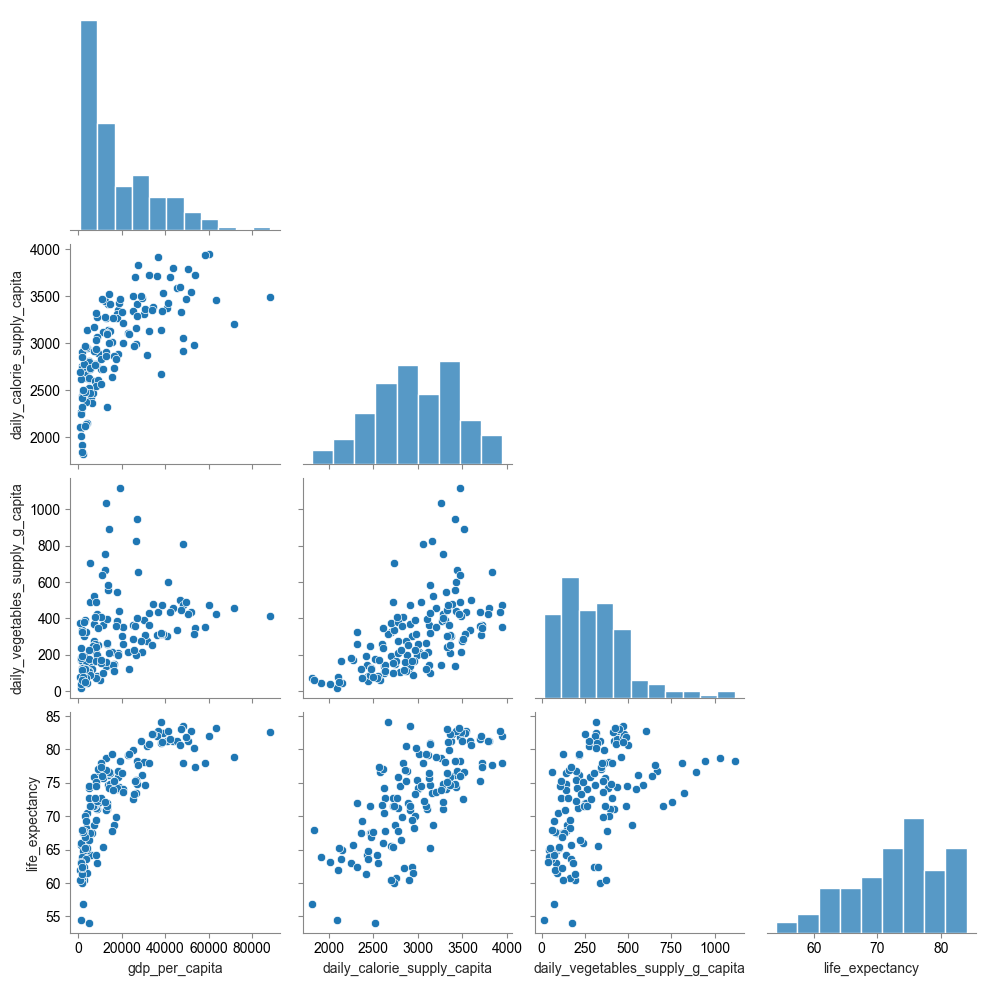

In [190]:
cols = ['gdp_per_capita',
       'daily_calorie_supply_capita', 'daily_vegetables_supply_g_capita', 'life_expectancy']

sns.pairplot(
    data_robust[cols + ['country_wb_income_group']],
    diag_kind='hist',
    corner=True
    )

Removing the CAR results in clearer picture. Diminishing returns positive relationship is observed for life expectancy as function of GDP. A bit more variable linear positive relationship can be observed for life expectancy as a function of calorie supply. Some positive relationship can be observed for vegetables supply but the nature of relation is less clear. 

It'll be interesting to observe the cluster of high vegetable supply observations and if they have any unexpected properties. For example - do they outperform expectations in life expectancy?

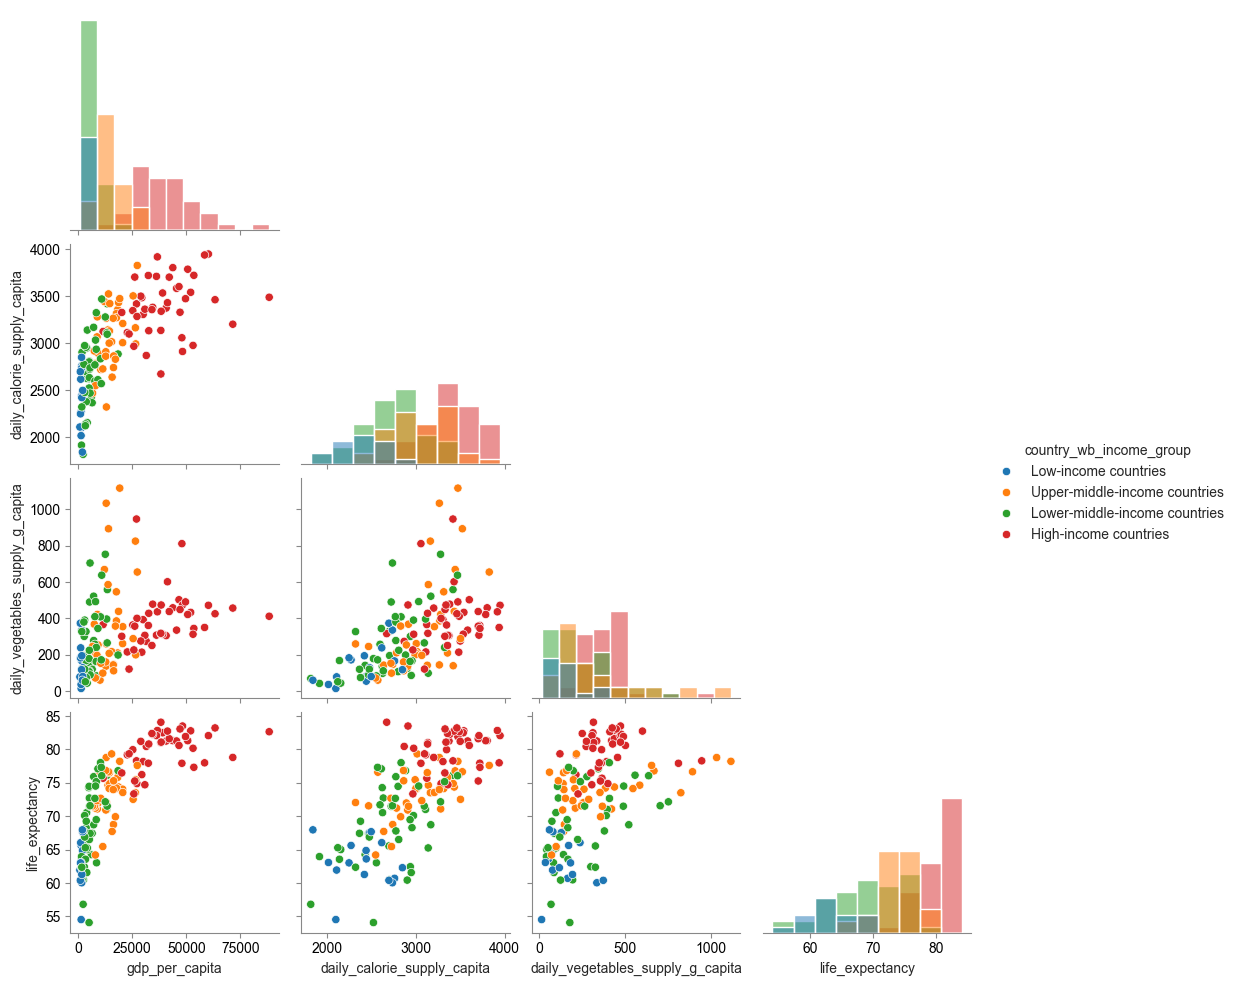

In [191]:
cols = ['gdp_per_capita',
       'daily_calorie_supply_capita', 'daily_vegetables_supply_g_capita', 'life_expectancy']

sns.pairplot(
    data_robust[cols + ['country_wb_income_group']],
    hue = 'country_wb_income_group',
    diag_kind='hist',
    corner=True
    )

Looking at the income groups it is clear that differences in distributions can be observed for different income groups, especially for GDP which is expected. But also for calorie supply and life expectancy.

In [192]:
corr_matrix = data_robust[['life_expectancy','gdp_per_capita', 'daily_calorie_supply_capita', 'daily_vegetables_supply_g_capita']].corr()

print(corr_matrix)

                                  life_expectancy  gdp_per_capita  \
life_expectancy                          1.000000        0.764716   
gdp_per_capita                           0.764716        1.000000   
daily_calorie_supply_capita              0.725705        0.688280   
daily_vegetables_supply_g_capita         0.487520        0.388182   

                                  daily_calorie_supply_capita  \
life_expectancy                                      0.725705   
gdp_per_capita                                       0.688280   
daily_calorie_supply_capita                          1.000000   
daily_vegetables_supply_g_capita                     0.579284   

                                  daily_vegetables_supply_g_capita  
life_expectancy                                           0.487520  
gdp_per_capita                                            0.388182  
daily_calorie_supply_capita                               0.579284  
daily_vegetables_supply_g_capita                    

Life expectancy appears to be especially strongly correlated with GPD and calorie supply.

In [193]:
corr_matrix = data_robust[['life_expectancy','gdp_per_capita', 'daily_calorie_supply_capita', 'daily_vegetables_supply_g_capita']].corr(method='spearman')

print(corr_matrix)

                                  life_expectancy  gdp_per_capita  \
life_expectancy                          1.000000        0.881022   
gdp_per_capita                           0.881022        1.000000   
daily_calorie_supply_capita              0.733657        0.789923   
daily_vegetables_supply_g_capita         0.576386        0.562700   

                                  daily_calorie_supply_capita  \
life_expectancy                                      0.733657   
gdp_per_capita                                       0.789923   
daily_calorie_supply_capita                          1.000000   
daily_vegetables_supply_g_capita                     0.673291   

                                  daily_vegetables_supply_g_capita  
life_expectancy                                           0.576386  
gdp_per_capita                                            0.562700  
daily_calorie_supply_capita                               0.673291  
daily_vegetables_supply_g_capita                    

In next step I'm going to look closer at each of the life expectancy relationships.

## Exploring relationships between life expectancy, GDP and nutritional variables

### Live expectancy vs. GDP

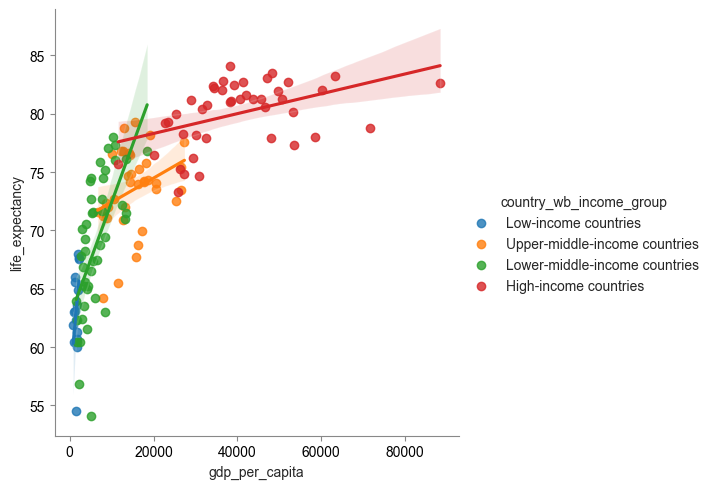

In [194]:
sns.lmplot(
    data=data_robust,
    x="gdp_per_capita",
    y="life_expectancy",
    hue="country_wb_income_group"
)

While there is a steep positive relationship between GDP and life expectancy for low and lower-middle income countries, it weakens for higher income countries suggesting diminishing returns of economic growth on health outcomes.

<Axes: xlabel='gdp_per_capita', ylabel='life_expectancy'>

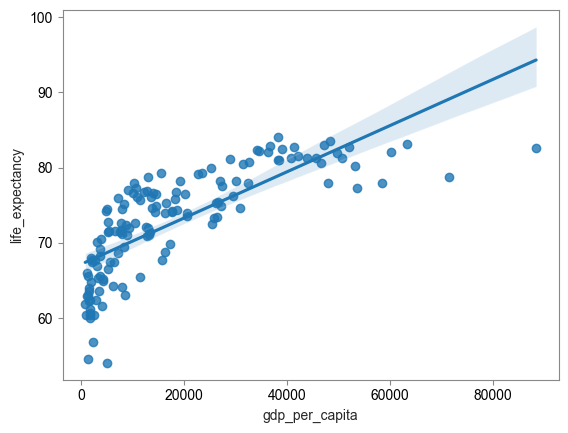

In [195]:
sns.regplot(
    data=data_robust,
    x="gdp_per_capita",
    y="life_expectancy"
)

Clearly the diminishing returns pattern can be observed here and using a logaritmic scale might result in a better model fit.

In [196]:
linear_model = smf.ols(
    "life_expectancy ~ gdp_per_capita",
    data=data_robust
).fit()

print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.585
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     195.8
Date:                Wed, 27 May 2026   Prob (F-statistic):           2.59e-28
Time:                        15:11:54   Log-Likelihood:                -411.89
No. Observations:                 141   AIC:                             827.8
Df Residuals:                     139   BIC:                             833.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         67.1654      0.555    120.

<Axes: >

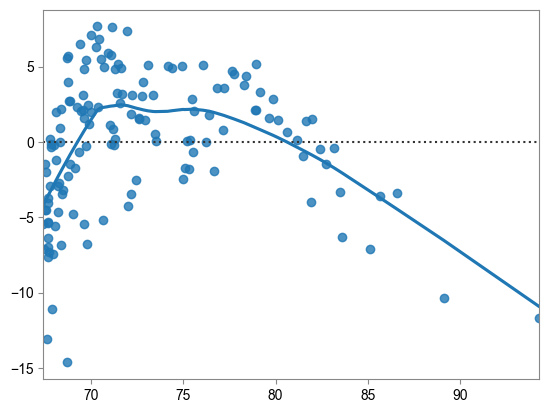

In [197]:
sns.residplot(
    x=linear_model.fittedvalues,
    y=linear_model.resid,
    lowess=True
)

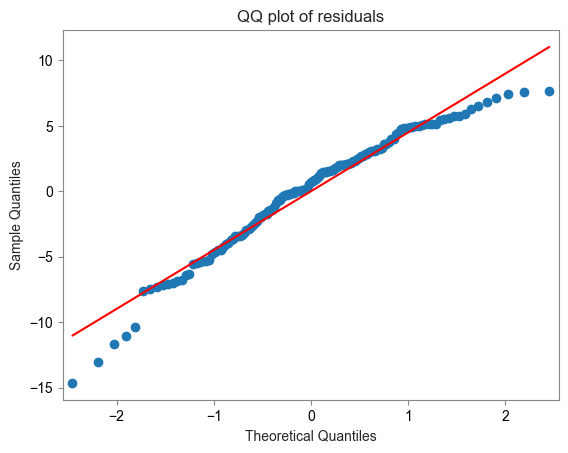

In [198]:
sm.qqplot(linear_model.resid, line='s')
plt.title("QQ plot of residuals")
plt.show()

Looking at the residuals, there is remaining non-linearity in the data and potential ommitted-variable effects. The linear model based on GDP only seems to overestimate the life expectancy for lower values (below 70 year old) then underestimate for values in the middle (70-82 years) and then again overestimate for the right tail of life expectancy. The model seems to perform worse at the extremes. 

### Life expectancy vs. log(GDP)

In [199]:
data_robust['log_gdp'] = np.log(data_robust['gdp_per_capita'])

<Axes: xlabel='log_gdp', ylabel='life_expectancy'>

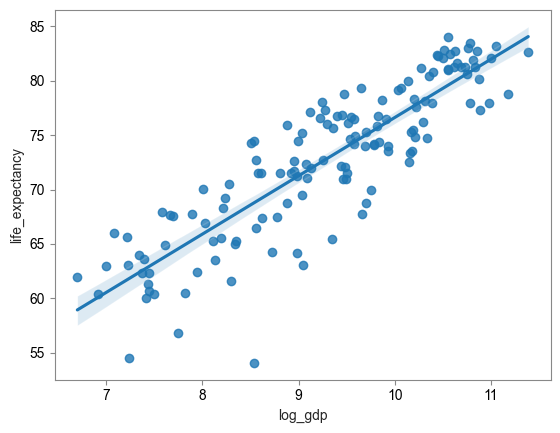

In [200]:
sns.regplot(
    data=data_robust,
    x="log_gdp",
    y="life_expectancy"
)

In [201]:
log_model = smf.ols(
    "life_expectancy ~ log_gdp",
    data=data_robust
).fit()

print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     445.9
Date:                Wed, 27 May 2026   Prob (F-statistic):           3.27e-45
Time:                        15:11:54   Log-Likelihood:                -372.55
No. Observations:                 141   AIC:                             749.1
Df Residuals:                     139   BIC:                             755.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.0679      2.374      9.719      0.0

The analysis shows a strong positive relationship between economic development and life expectancy across countries. A linear specification between GDP per capita and life expectancy explains a substantial portion of cross-country variation, but the fit improves considerably when GDP is log-transformed (R² increasing from 0.59 to 0.76). This suggests that the relationship exhibits diminishing returns: increases in income are associated with much larger improvements in life expectancy among lower-income countries than among wealthier ones. The logarithmic specification also improves numerical stability and better reflects the underlying structure visible in the data.

The log-linear model explains approximately 76% of cross-country variation in life expectancy. A doubling of GDP per capita is associated with roughly 3.7 additional years of life expectancy on average.

<Axes: >

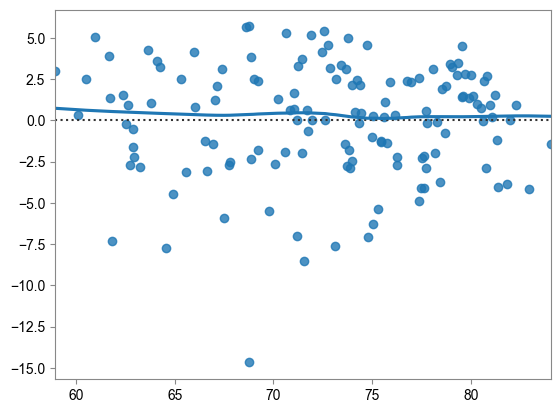

In [202]:
sns.residplot(
    x=log_model.fittedvalues,
    y=log_model.resid,
    lowess=True
)

The residuals are closer to normal than in case of the linear model. However there still seems to be some non-linearity in the data, especially for poorer countries. The variability is higher among countries with lower life expectancy which is not unexpected given the nature of countries with lower GPD being less predictable.

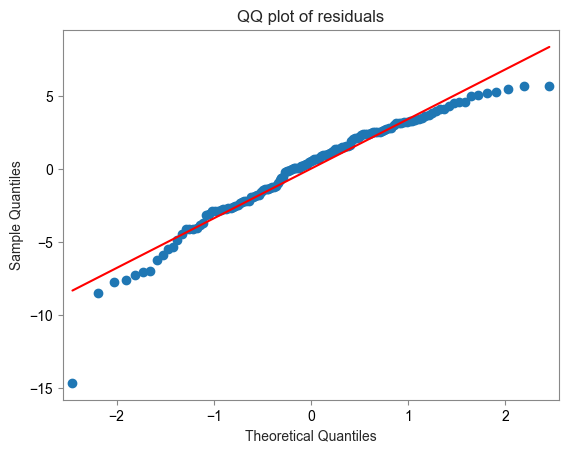

In [203]:
sm.qqplot(log_model.resid, line='s')
plt.title("QQ plot of residuals")
plt.show()

The QQ plot suggests that the residuals are not perfectly normally distributed, though deviations from normality are moderate. We observe several large negative residuals, resulting in a heavier left tail and slight negative skewness, while the right tail appears somewhat lighter than expected under normality. Overall, this indicates the presence of a few countries for which the model substantially overestimates life expectancy, rather than a strong systematic bias across the dataset.

Next steps - looking at how well calories explain variability in life expectancy, then doing the same for vegetables and then combining all the explanatory variables.

### Life expectancy vs. calories supply

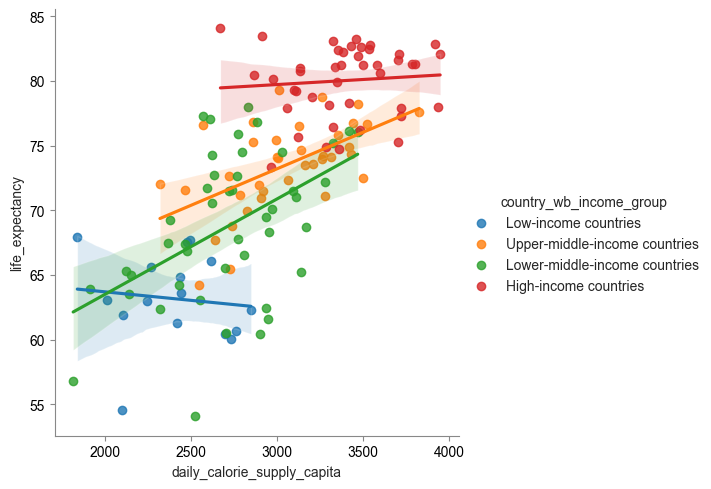

In [204]:
sns.lmplot(
    data=data_robust,
    x="daily_calorie_supply_capita",
    y="life_expectancy",
    hue="country_wb_income_group"
)

The resuls clustered per income group indicate a positive relationship between calorie intake for all groups except for the low-income countries. Most probably for those countries other factors are more detrimental than calories. Also note that the confidence intervals are rather wide indicating a lot of uncertainty around the fitted regression lines.

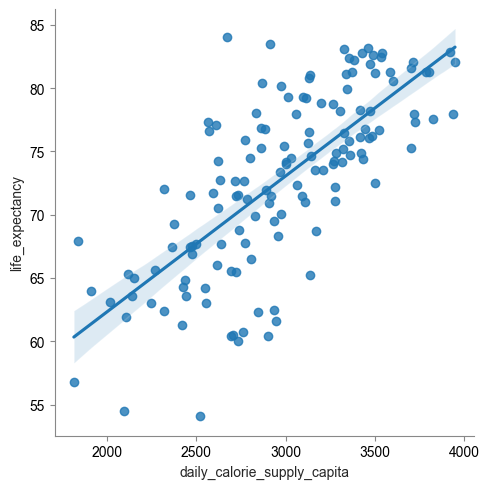

In [205]:
sns.lmplot(
    data=data_robust,
    x="daily_calorie_supply_capita",
    y="life_expectancy"
)

There seems to be a positive linear relationship between the calorie supply and life expectancy. 

In [206]:
linear_model = smf.ols(
    "life_expectancy ~ daily_calorie_supply_capita",
    data=data_robust
).fit()

print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.523
Method:                 Least Squares   F-statistic:                     154.7
Date:                Wed, 27 May 2026   Prob (F-statistic):           2.46e-24
Time:                        15:11:56   Log-Likelihood:                -421.13
No. Observations:                 141   AIC:                             846.3
Df Residuals:                     139   BIC:                             852.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [207]:
data_robust['calories_thousands'] = data_robust['daily_calorie_supply_capita']/1000

linear_model = smf.ols(
    "life_expectancy ~ calories_thousands",
    data=data_robust
).fit()

print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.523
Method:                 Least Squares   F-statistic:                     154.7
Date:                Wed, 27 May 2026   Prob (F-statistic):           2.46e-24
Time:                        15:11:56   Log-Likelihood:                -421.13
No. Observations:                 141   AIC:                             846.3
Df Residuals:                     139   BIC:                             852.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             40.8462      2

The fit is much worse than for log of GDP. Only about 52% data variability can be explained by the calorie supply. The positive relationship still exists and is statistically signifficant but there is a high chance that the calories supply is actually a proxy for economic situation of a country and does not have explanatory power of its own. It's important to note that the model has less (but still negative) skew than the log(GDP) model indicating that it might be capturing some variability better than the previous one. Also, the residuals are more likely to be normal than in case of log(GDP) - looking at Jarque-Bera test.

<Axes: >

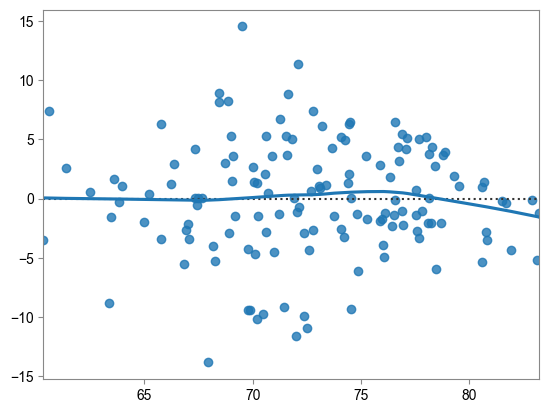

In [208]:
sns.residplot(
    x=linear_model.fittedvalues,
    y=linear_model.resid,
    lowess=True
)

The residuals indicate some residual non-linearity in the data for developed countries. Especially for the countries with the highest life expectancy there seem to be a systemic overestimation of the life expectancy. This makes sense as calorie intake might have positive impact on life expectancy up to a certain point but at certain point the effect most probably tapers and might even reverse in the extreme.

### Life expectancy vs. vegetables supply

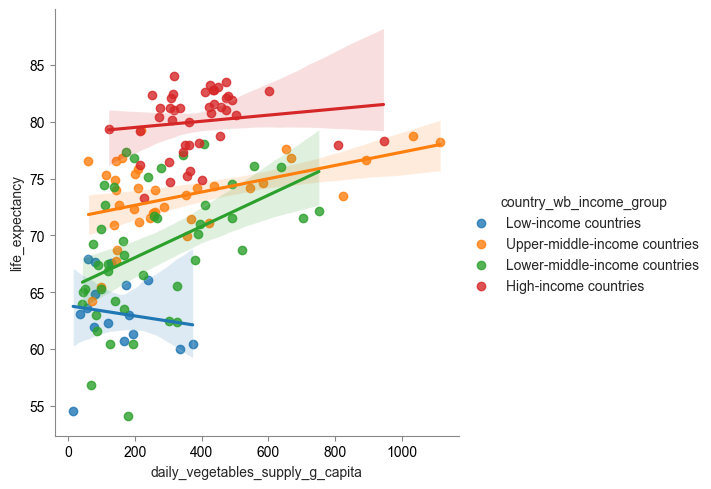

In [209]:
sns.lmplot(
    data=data_robust,
    x="daily_vegetables_supply_g_capita",
    y="life_expectancy",
    hue="country_wb_income_group"
)


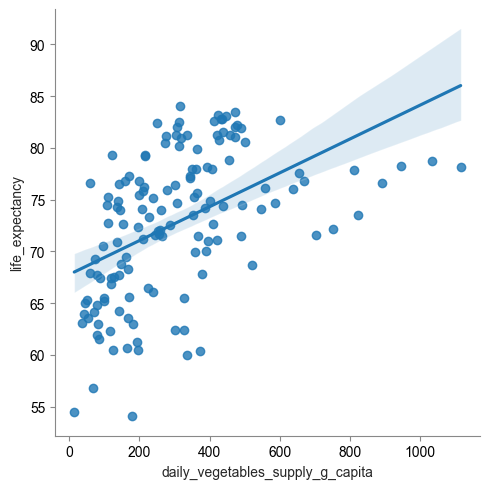

In [210]:
sns.lmplot(
    data=data_robust,
    x="daily_vegetables_supply_g_capita",
    y="life_expectancy"
)

In [211]:
linear_model = smf.ols(
    "life_expectancy ~ daily_vegetables_supply_g_capita",
    data=data_robust
).fit()

print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     43.34
Date:                Wed, 27 May 2026   Prob (F-statistic):           8.73e-10
Time:                        15:11:57   Log-Likelihood:                -454.73
No. Observations:                 141   AIC:                             913.5
Df Residuals:                     139   BIC:                             919.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

The fit is much weaker than the previous two models. There is a positive linear relation between vegetable supply and life expectancy but it does not explain a lot of variability in the data.

<Axes: >

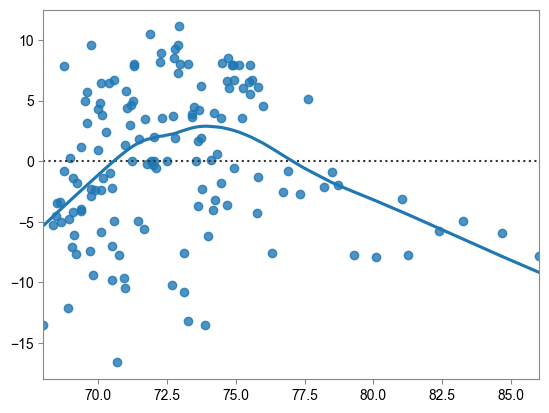

In [212]:
sns.residplot(
    x=linear_model.fittedvalues,
    y=linear_model.resid,
    lowess=True
)

Residuals also support the weak model fit result. 

In [213]:

multivariate_model = smf.ols(
    "life_expectancy ~ log_gdp + calories_thousands + daily_vegetables_supply_g_capita",
    data=data_robust
).fit()

print(multivariate_model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     155.9
Date:                Wed, 27 May 2026   Prob (F-statistic):           5.56e-44
Time:                        15:11:57   Log-Likelihood:                -369.18
No. Observations:                 141   AIC:                             746.4
Df Residuals:                     137   BIC:                             758.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

## Multivariate models of life expectancy

### Life expectancy vs. log(GDP) + calories supply

In [214]:
multivariate_model = smf.ols(
    "life_expectancy ~ log_gdp + calories_thousands",
    data=data_robust
).fit()

print(multivariate_model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     228.2
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.73e-44
Time:                        15:11:57   Log-Likelihood:                -370.90
No. Observations:                 141   AIC:                             747.8
Df Residuals:                     138   BIC:                             756.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             23.0986      2

### Life expectancy vs. log(GDP) + vegetables supply

In [215]:
data_robust['daily_vegetables_supply_kg_capita'] = data_robust['daily_vegetables_supply_g_capita']/1000

multivariate_model = smf.ols(
    "life_expectancy ~ log_gdp + daily_vegetables_supply_kg_capita",
    data=data_robust
).fit()

print(multivariate_model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     233.6
Date:                Wed, 27 May 2026   Prob (F-statistic):           4.98e-45
Time:                        15:11:57   Log-Likelihood:                -369.63
No. Observations:                 141   AIC:                             745.3
Df Residuals:                     138   BIC:                             754.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

Out of the two multivariate models (log(GDP) with calorie supply and log(GDP) with vegetables supply), the model including vegetables supply seems to present a slightly bigger improvement to the overall model fit. However the improvement remains modest, with R2 increasing only from 0.762 in the original log(GDP) model to approximately 0.772. This suggest that GDP already explains most of the variation in life expectancy accross countries.

Additionally looking at the coefficient estimates, vegetables supply of a country seems to be positively associated with life expectancy, even after controlling for GDP with a positive confidence interval and a statistically signifficant p-value. In contrast, calorie supply does not remain statistically signifficant after controlling for GDP. This might suggest that the vegetable supply captures aspects of diet quality that can't be explained by calorie availability alone.

Based on the estimated coefficient, an increase of 100 g in daily vegetable supply per capita is associated with an increase in predicted life expectancy of approximately 0.37 years (around 4.5 months), holding GDP constant.

While the additional explanatory power is limited, the result suggests that nutritional composition may contribute information beyond economic development alone.

<Axes: >

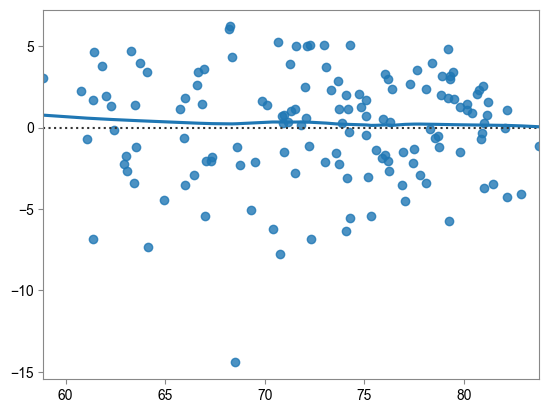

In [216]:
sns.residplot(
    x=multivariate_model.fittedvalues,
    y=multivariate_model.resid,
    lowess=True
)

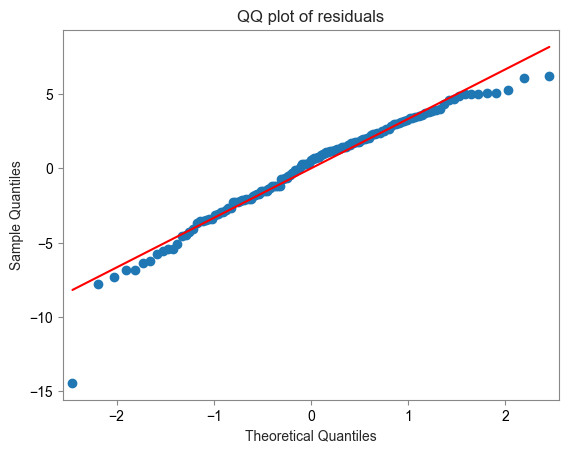

In [217]:
sm.qqplot(multivariate_model.resid, line='s')
plt.title("QQ plot of residuals")
plt.show()

Looking at residual plots also suggest a very modest improvement in model fit.

### Life expectancy vs. log(GDP) * vegetables supply

In [218]:
multivariate_interaction_model = smf.ols(
    "life_expectancy ~ log_gdp * daily_vegetables_supply_kg_capita",
    data=data_robust
).fit()

print(multivariate_interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     155.4
Date:                Wed, 27 May 2026   Prob (F-statistic):           6.59e-44
Time:                        15:11:58   Log-Likelihood:                -369.35
No. Observations:                 141   AIC:                             746.7
Df Residuals:                     137   BIC:                             758.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

Testing for interaction there doesn't seem to be evidence for different effect of vegetables on life expectancy depending on the GDP levels. Adding an interaction variable results in high p-values for both the vegetable supply variable and the interaction between GDP and vegetables variable.

## Vegetable supply positive outliers exploration

In [219]:
iqr = data_robust['daily_vegetables_supply_kg_capita'].quantile(0.75) - data_robust['daily_vegetables_supply_kg_capita'].quantile(0.25)

iqr

np.float64(0.2673153698630137)

In [220]:
data_robust['pos_veg_outliers'] = data_robust['daily_vegetables_supply_kg_capita'] > 1.5 * iqr

In [221]:
data_robust['pos_veg_outliers'].sum()/data_robust['pos_veg_outliers'].count()

np.float64(0.2695035460992908)

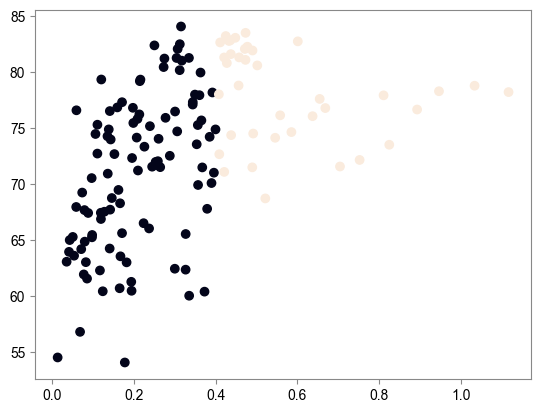

In [222]:
plt.scatter(data_robust['daily_vegetables_supply_kg_capita'], data_robust['life_expectancy'], c = data_robust['pos_veg_outliers'])

Too much data counts as outliers in this case. Data is way sparser than expected from the IQR outliers heuristic. 

In [223]:
data_robust['pos_veg_outliers'] = data_robust['daily_vegetables_supply_kg_capita'] > 2 * iqr

In [224]:
data_robust['pos_veg_outliers'].sum()/data_robust['pos_veg_outliers'].count()

np.float64(0.10638297872340426)

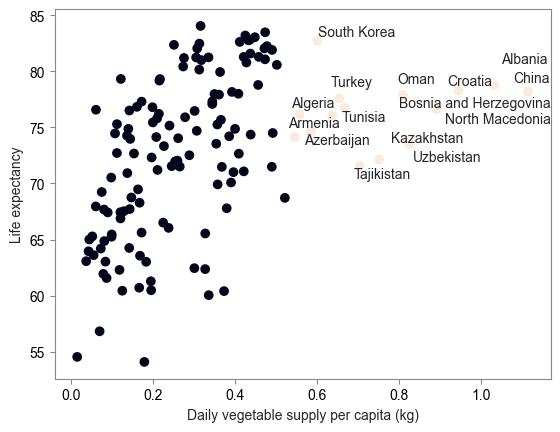

In [225]:
plt.scatter(data_robust['daily_vegetables_supply_kg_capita'], data_robust['life_expectancy'], c = data_robust['pos_veg_outliers'])

texts = []

# annotate only flagged observations
for _, row in data_robust[data_robust['pos_veg_outliers']].iterrows():
    texts.append(
        plt.text(
        row['daily_vegetables_supply_kg_capita'],
        row['life_expectancy'],
        row['country']
        )
    )

adjust_text(texts)

plt.xlabel('Daily vegetable supply per capita (kg)')
plt.ylabel('Life expectancy')

plt.show()

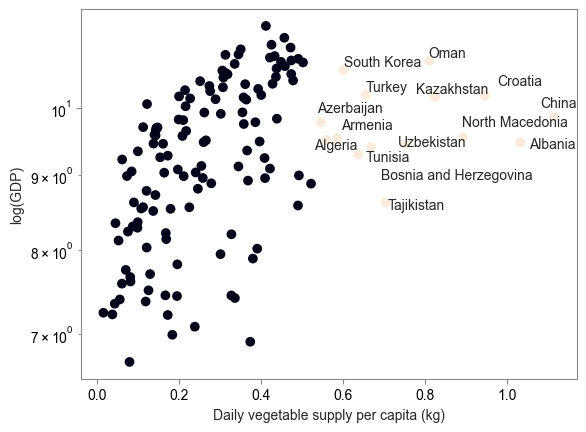

In [226]:
plt.scatter(data_robust['daily_vegetables_supply_kg_capita'], data_robust['log_gdp'], c = data_robust['pos_veg_outliers'])

texts = []

# annotate only flagged observations
for _, row in data_robust[data_robust['pos_veg_outliers']].iterrows():
    texts.append(
        plt.text(
        row['daily_vegetables_supply_kg_capita'],
        row['log_gdp'],
        row['country']
        )
    )

adjust_text(texts)

plt.xlabel('Daily vegetable supply per capita (kg)')
plt.yscale('log')
plt.ylabel('log(GDP)')

plt.show()

Number of countries has an unusually high vegetable consumption. The countries mainly lie in the Balkans (Croatia, North Macedonia, Turkey, Albania, Bosnia and Herzegovina), Central Asia (Kazakhstan, Uzbekistan, Tajikistan), East Asia (China, South Korea), West Asia (Azerbaijan, Armenia), North Africa (Algeria, Tunisia) and Middle East (Oman). The cusines of these countries which are centered around vegetables align with this observation. Additionally, according to World Integrated Trade Solution, China is also the biggest vegetable exporter in the world which might explain why it has the highest vegetable supply per capita. 

In [227]:
log_gdp_model = smf.ols(
    "life_expectancy ~ log_gdp",
    data=data_robust
).fit()

data_robust['prediction_log_gdp'] = log_gdp_model.fittedvalues

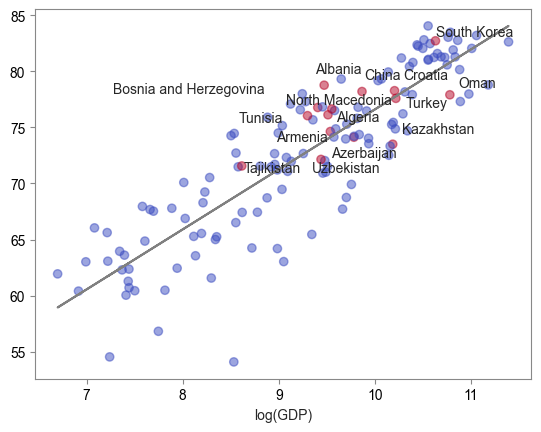

In [228]:
plt.plot(data_robust['log_gdp'], data_robust['prediction_log_gdp'], color = 'grey')
plt.scatter(data_robust['log_gdp'], data_robust['life_expectancy'], c = data_robust['pos_veg_outliers'], alpha=0.5, cmap='coolwarm')

texts = []

# annotate only flagged observations
for _, row in data_robust[data_robust['pos_veg_outliers']].iterrows():
    texts.append(
        plt.text(
        row['log_gdp'],
        row['life_expectancy'],
        row['country']
        )
    )

adjust_text(texts)

plt.xlabel('Life expectancy')
plt.xlabel('log(GDP)')

plt.show()

There does not seem to be a pattern among the high vegetable producers in which they systematically perform better than GDP would indicate. There seem to be more countries above than below the relationship predicted by the model but the relationship is not strong enough to draw any conclusions. 